In [24]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

# import local libraries
import src.utils.config as config
import src.proc.process_behavior_signals as pbs
# import proc.organize as org
import src.utils.data_io as dio
import src.utils.pdata_io as pdio
import numpy as np


# print(config.PROJECT_ROOT)
# print(config.RAW_BASE)
# print(config.PROC_BASE)

import sys
from pathlib import Path

CODE_BASE = Path(config.CODE_BASE).expanduser()
sys.path.append(str(CODE_BASE))

print("Added to path:", CODE_BASE)

# make the data dictionary which contains list of all animals and sessions and
# file names of videos h264 and mat files

data_root = config.RAW_BASE # this variable now contains the path to the raw data directory, which is defined in the config file. It is used to build the classical conditioning data dictionary using the dio.build_classical_conditioning_dict function. The resulting cc_data variable will contain the structured information about the animals, sessions, and file names for the classical conditioning experiments.
cc_data = dio.build_classical_conditioning_dict(data_root)

pdata_root = config.PROC_BASE # this variable now contains the path to the processed data directory, which is defined in the config file. It is used to build the processed data dictionary using the pdio.build_processed_data_dict function. The resulting pdata variable will contain the structured information about the animals, sessions, and file names for the processed data of the classical conditioning experiments.
print(data_root)
print(pdata_root)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Added to path: /home/nmldata2/ccaw/Python
/mnt/data/Classical_Conditioning
/mnt/pdata/Classical_Conditioning


In [25]:
from __future__ import annotations

from dataclasses import dataclass
from fractions import Fraction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import (
    butter,
    savgol_filter,
    sosfiltfilt,
    resample_poly,
    welch,
    stft,
)

import src.utils.pdata_io as pdio


# =============================================================================
# Native-rate encoder spectral analysis
# =============================================================================

@dataclass
class NativeSpectralConfig:
    """
    Configuration for deriving spectral-analysis velocity from the
    native encoder-derived position signal.
    """

    # Final sampling rate after native-rate processing.
    analysis_hz: float = 100.0

    # Short differentiation window applied at the original sampling rate.
    derivative_window_ms: float = 20.0
    derivative_polyorder: int = 3

    # Low-pass filter for the newly derived signed velocity.
    speed_lowpass_hz: float = 20.0
    filter_order: int = 4

    # Welch PSD settings.
    welch_window_s: float = 10.0
    welch_overlap_fraction: float = 0.50

    # STFT settings.
    stft_window_s: float = 2.0
    stft_step_s: float = 0.20

    # Frequencies displayed and retained.
    fmax_hz: float = 20.0


def _valid_odd_window(
    window_ms: float,
    fs: float,
    polyorder: int,
    signal_length: int,
) -> int:
    """
    Return a valid odd Savitzky-Golay window length.
    """

    window = int(
        round(
            window_ms / 1000.0 * fs
        )
    )

    if window % 2 == 0:
        window += 1

    minimum_window = polyorder + 2

    if minimum_window % 2 == 0:
        minimum_window += 1

    window = max(
        window,
        minimum_window,
    )

    maximum_window = (
        signal_length
        if signal_length % 2 == 1
        else signal_length - 1
    )

    window = min(
        window,
        maximum_window,
    )

    if window <= polyorder:
        raise ValueError(
            "Signal is too short for the requested "
            "Savitzky-Golay derivative."
        )

    return window


def _lowpass_zero_phase(
    signal: np.ndarray,
    fs: float,
    cutoff_hz: float,
    order: int = 4,
) -> np.ndarray:
    """
    Apply a Butterworth zero-phase low-pass filter.
    """

    signal = np.asarray(
        signal,
        dtype=np.float64,
    )

    nyquist_hz = fs / 2.0

    if not 0 < cutoff_hz < nyquist_hz:
        raise ValueError(
            f"cutoff_hz must be between 0 and {nyquist_hz}."
        )

    sos = butter(
        N=order,
        Wn=cutoff_hz,
        btype="lowpass",
        fs=fs,
        output="sos",
    )

    return sosfiltfilt(
        sos,
        signal,
    )


def _resample_continuous(
    signal: np.ndarray,
    original_hz: float,
    target_hz: float,
) -> np.ndarray:
    """
    Resample a continuous signal using polyphase anti-alias filtering.
    """

    ratio = Fraction(
        target_hz / original_hz
    ).limit_denominator(100000)

    return resample_poly(
        np.asarray(signal),
        up=ratio.numerator,
        down=ratio.denominator,
    )


def _downsample_cumulative_signal(
    signal: np.ndarray,
    original_hz: float,
    target_hz: float,
) -> np.ndarray:
    """
    Downsample cumulative position by retaining the last sample
    in each block when the sampling-rate ratio is integral.
    """

    ratio = original_hz / target_hz
    block_size = int(round(ratio))

    if np.isclose(
        ratio,
        block_size,
    ):
        number_of_blocks = (
            len(signal) // block_size
        )

        trimmed = np.asarray(signal)[
            :number_of_blocks * block_size
        ]

        return trimmed.reshape(
            number_of_blocks,
            block_size,
        )[:, -1]

    # General fallback for nonintegral ratios.
    original_time = (
        np.arange(len(signal)) /
        original_hz
    )

    target_time = np.arange(
        0,
        original_time[-1],
        1.0 / target_hz,
    )

    return np.interp(
        target_time,
        original_time,
        signal,
    )


def _downsample_binary(
    signal: np.ndarray,
    original_hz: float,
    target_hz: float,
) -> np.ndarray:
    """
    Downsample a binary signal using majority occupancy.
    """

    ratio = original_hz / target_hz
    block_size = int(round(ratio))

    if np.isclose(
        ratio,
        block_size,
    ):
        number_of_blocks = (
            len(signal) // block_size
        )

        trimmed = np.asarray(signal)[
            :number_of_blocks * block_size
        ]

        block_fraction = trimmed.reshape(
            number_of_blocks,
            block_size,
        ).mean(axis=1)

        return (
            block_fraction >= 0.5
        ).astype(np.int8)

    resampled = _resample_continuous(
        signal,
        original_hz,
        target_hz,
    )

    return (
        resampled >= 0.5
    ).astype(np.int8)


def _binary_from_edges(
    number_of_samples: int,
    air_r: np.ndarray,
    air_f: np.ndarray,
) -> np.ndarray:
    """
    Reconstruct a binary control signal from rising and falling edges.

    Air_f is interpreted as the final high sample.
    """

    binary = np.zeros(
        number_of_samples,
        dtype=np.int8,
    )

    for onset, final_high in zip(
        np.asarray(air_r, dtype=np.int64),
        np.asarray(air_f, dtype=np.int64),
    ):
        start = max(
            0,
            int(onset),
        )

        end = min(
            number_of_samples,
            int(final_high) + 1,
        )

        binary[start:end] = 1

    return binary


def _reconstruct_tone_100hz(
    number_of_samples: int,
    air_r: np.ndarray,
    original_fs: float,
    analysis_hz: float,
    tone_before_air_s: float = 3.0,
    tone_after_air_s: float = 2.0,
) -> np.ndarray:
    """
    Reconstruct the protocol-defined tone signal at the analysis rate.
    """

    tone = np.zeros(
        number_of_samples,
        dtype=np.int8,
    )

    for air_onset_sample in np.asarray(
        air_r,
        dtype=np.int64,
    ):
        air_onset_s = (
            air_onset_sample /
            original_fs
        )

        start = int(
            round(
                (
                    air_onset_s -
                    tone_before_air_s
                ) *
                analysis_hz
            )
        )

        end = int(
            round(
                (
                    air_onset_s +
                    tone_after_air_s
                ) *
                analysis_hz
            )
        )

        start = max(
            0,
            start,
        )

        end = min(
            number_of_samples,
            end,
        )

        tone[start:end] = 1

    return tone


def derive_native_encoder_speed(
    position_cm: np.ndarray,
    fs: float,
    spectral_config: NativeSpectralConfig,
) -> tuple[np.ndarray, dict]:
    """
    Derive signed velocity from native-rate encoder position.

    The derivative is calculated at the original rate using a short
    Savitzky-Golay window and then low-pass filtered.
    """

    position_cm = np.asarray(
        position_cm,
        dtype=np.float64,
    )

    derivative_window = _valid_odd_window(
        window_ms=(
            spectral_config.derivative_window_ms
        ),
        fs=fs,
        polyorder=(
            spectral_config.derivative_polyorder
        ),
        signal_length=len(position_cm),
    )

    signed_speed_native = savgol_filter(
        position_cm,
        window_length=derivative_window,
        polyorder=(
            spectral_config.derivative_polyorder
        ),
        deriv=1,
        delta=1.0 / fs,
        mode="interp",
    )

    signed_speed_native = _lowpass_zero_phase(
        signal=signed_speed_native,
        fs=fs,
        cutoff_hz=(
            spectral_config.speed_lowpass_hz
        ),
        order=(
            spectral_config.filter_order
        ),
    )

    metadata = {
        "derivative_window_samples": (
            derivative_window
        ),
        "derivative_window_ms_actual": (
            derivative_window / fs * 1000
        ),
        "speed_lowpass_hz": (
            spectral_config.speed_lowpass_hz
        ),
    }

    return signed_speed_native, metadata


def build_native_spectral_timeseries(
    animal: str,
    date: str,
    cc_data: dict | None = None,
    spectral_config: NativeSpectralConfig | None = None,
    root=None,
):
    """
    Build a 100-Hz spectral-analysis time series from native-rate
    encoder position.

    Returns
    -------
    spectral_df : pandas.DataFrame
        Time, native-derived velocity, stored velocity, position,
        and environmental signals.

    metadata : dict
        Processing settings and session information.
    """

    if spectral_config is None:
        spectral_config = NativeSpectralConfig()

    load_kwargs = {}

    if root is not None:
        load_kwargs["root"] = root

    available_keys = pdio.list_behavior_h5_keys(
        animal,
        date,
        **load_kwargs,
    )

    if available_keys is None:
        raise FileNotFoundError(
            f"No behavior_v1.h5 found for {animal}, {date}."
        )

    required_keys = [
        "fs",
        "dist_net_cm",
        "speed_net_cms",
    ]

    missing = [
        key
        for key in required_keys
        if key not in available_keys
    ]

    if missing:
        raise KeyError(
            f"Missing required H5 variables: {missing}"
        )

    optional_keys = [
        key
        for key in [
            "speed_path_cms",
            "air_bin",
            "Air_r",
            "Air_f",
        ]
        if key in available_keys
    ]

    behavior = pdio.load_behavior_h5(
        animal,
        date,
        keys=required_keys + optional_keys,
        **load_kwargs,
    )

    fs = float(
        np.asarray(
            behavior["fs"]
        ).squeeze()
    )

    position_native = np.asarray(
        behavior["dist_net_cm"],
        dtype=np.float64,
    )

    stored_speed_native = np.asarray(
        behavior["speed_net_cms"],
        dtype=np.float64,
    )

    # -------------------------------------------------------------------------
    # Derive velocity from the native 5,000-Hz position signal
    # -------------------------------------------------------------------------

    (
        encoder_speed_native,
        derivative_metadata,
    ) = derive_native_encoder_speed(
        position_cm=position_native,
        fs=fs,
        spectral_config=spectral_config,
    )

    # -------------------------------------------------------------------------
    # Downsample after native-rate differentiation/filtering
    # -------------------------------------------------------------------------

    encoder_speed_ds = _resample_continuous(
        encoder_speed_native,
        original_hz=fs,
        target_hz=(
            spectral_config.analysis_hz
        ),
    )

    stored_speed_ds = _resample_continuous(
        stored_speed_native,
        original_hz=fs,
        target_hz=(
            spectral_config.analysis_hz
        ),
    )

    position_ds = _downsample_cumulative_signal(
        position_native,
        original_hz=fs,
        target_hz=(
            spectral_config.analysis_hz
        ),
    )

    number_of_samples = min(
        len(encoder_speed_ds),
        len(stored_speed_ds),
        len(position_ds),
    )

    encoder_speed_ds = encoder_speed_ds[
        :number_of_samples
    ]

    stored_speed_ds = stored_speed_ds[
        :number_of_samples
    ]

    position_ds = position_ds[
        :number_of_samples
    ]

    position_ds = (
        position_ds -
        position_ds[0]
    )

    analysis_time_s = (
        np.arange(number_of_samples) /
        spectral_config.analysis_hz
    )

    # -------------------------------------------------------------------------
    # Environmental signals
    # -------------------------------------------------------------------------

    phase = "unknown"

    if cc_data is not None:
        phase = (
            cc_data
            .get(animal, {})
            .get(date, {})
            .get("phase", "unknown")
        )

    control_native = None

    if "air_bin" in behavior:
        control_native = np.asarray(
            behavior["air_bin"],
            dtype=np.int8,
        )

    elif (
        "Air_r" in behavior
        and "Air_f" in behavior
    ):
        control_native = _binary_from_edges(
            number_of_samples=len(
                position_native
            ),
            air_r=behavior["Air_r"],
            air_f=behavior["Air_f"],
        )

    if control_native is not None:
        control_ds = _downsample_binary(
            control_native,
            original_hz=fs,
            target_hz=(
                spectral_config.analysis_hz
            ),
        )

        control_ds = control_ds[
            :number_of_samples
        ]

    else:
        control_ds = np.zeros(
            number_of_samples,
            dtype=np.int8,
        )

    led_on = np.zeros(
        number_of_samples,
        dtype=np.int8,
    )

    air_on = np.zeros(
        number_of_samples,
        dtype=np.int8,
    )

    tone_on = np.zeros(
        number_of_samples,
        dtype=np.int8,
    )

    if phase == "habituation":
        led_on = control_ds

    elif phase in [
        "air_training",
        "tone_air_training",
    ]:
        air_on = control_ds

    else:
        air_on = control_ds

    if (
        phase == "tone_air_training"
        and "Air_r" in behavior
    ):
        tone_on = _reconstruct_tone_100hz(
            number_of_samples=number_of_samples,
            air_r=behavior["Air_r"],
            original_fs=fs,
            analysis_hz=(
                spectral_config.analysis_hz
            ),
        )

    spectral_df = pd.DataFrame(
        {
            "animal": animal,
            "date": date,
            "phase": phase,

            "time_s": analysis_time_s,

            "position_net_session_cm": (
                position_ds
            ),

            "speed_encoder_derived_cms": (
                encoder_speed_ds
            ),

            "speed_encoder_path_cms": np.abs(
                encoder_speed_ds
            ),

            "speed_stored_cms": (
                stored_speed_ds
            ),

            "speed_stored_path_cms": np.abs(
                stored_speed_ds
            ),

            "led_on": led_on,
            "air_on": air_on,
            "tone_on": tone_on,
        }
    )

    metadata = {
        "animal": animal,
        "date": date,
        "phase": phase,

        "original_fs": fs,
        "analysis_hz": (
            spectral_config.analysis_hz
        ),

        **derivative_metadata,

        "spectral_config": (
            spectral_config
        ),
    }

    spectral_df.attrs.update(
        metadata
    )

    return spectral_df, metadata


def calculate_speed_psd(
    speed: np.ndarray,
    fs: float,
    window_s: float = 10.0,
    overlap_fraction: float = 0.50,
    fmax_hz: float = 20.0,
) -> pd.DataFrame:
    """
    Calculate Welch power spectral density.
    """

    speed = np.asarray(
        speed,
        dtype=np.float64,
    )

    speed = speed[
        np.isfinite(speed)
    ]

    nperseg = min(
        len(speed),
        max(
            8,
            int(round(window_s * fs)),
        ),
    )

    noverlap = int(
        round(
            nperseg *
            overlap_fraction
        )
    )

    noverlap = min(
        noverlap,
        nperseg - 1,
    )

    frequency_hz, power = welch(
        speed,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density",
    )

    keep = (
        frequency_hz <= fmax_hz
    )

    return pd.DataFrame(
        {
            "frequency_hz": (
                frequency_hz[keep]
            ),
            "power": power[keep],
        }
    )


def calculate_speed_stft(
    speed: np.ndarray,
    fs: float,
    window_s: float = 2.0,
    step_s: float = 0.20,
    fmax_hz: float = 20.0,
):
    """
    Calculate an STFT spectrogram.
    """

    speed = np.asarray(
        speed,
        dtype=np.float64,
    )

    nperseg = max(
        8,
        int(round(window_s * fs)),
    )

    step_samples = max(
        1,
        int(round(step_s * fs)),
    )

    noverlap = max(
        0,
        nperseg - step_samples,
    )

    frequency_hz, time_s, complex_stft = stft(
        speed,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        boundary=None,
        padded=False,
    )

    power = (
        np.abs(complex_stft) ** 2
    )

    keep = (
        frequency_hz <= fmax_hz
    )

    frequency_hz = frequency_hz[
        keep
    ]

    power = power[
        keep,
        :
    ]

    power_db = 10 * np.log10(
        power +
        np.finfo(float).eps
    )

    return (
        frequency_hz,
        time_s,
        power,
        power_db,
    )


def plot_speed_psd_comparison(
    spectral_df,
    spectral_config=None,
):
    """
    Compare the PSD of the newly derived native-encoder speed with
    the previously stored 100-ms-window speed.
    """

    if spectral_config is None:
        spectral_config = (
            spectral_df.attrs[
                "spectral_config"
            ]
        )

    fs = spectral_config.analysis_hz

    encoder_psd = calculate_speed_psd(
        spectral_df[
            "speed_encoder_derived_cms"
        ],
        fs=fs,
        window_s=(
            spectral_config.welch_window_s
        ),
        overlap_fraction=(
            spectral_config
            .welch_overlap_fraction
        ),
        fmax_hz=(
            spectral_config.fmax_hz
        ),
    )

    stored_psd = calculate_speed_psd(
        spectral_df[
            "speed_stored_cms"
        ],
        fs=fs,
        window_s=(
            spectral_config.welch_window_s
        ),
        overlap_fraction=(
            spectral_config
            .welch_overlap_fraction
        ),
        fmax_hz=(
            spectral_config.fmax_hz
        ),
    )

    fig, ax = plt.subplots(
        figsize=(10, 5)
    )

    ax.semilogy(
        encoder_psd["frequency_hz"],
        encoder_psd["power"],
        label="Native encoder-derived speed",
    )

    ax.semilogy(
        stored_psd["frequency_hz"],
        stored_psd["power"],
        label="Stored 100-ms-window speed",
        alpha=0.8,
    )

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel(
        "Power spectral density "
        "[(cm/s)²/Hz]"
    )

    ax.set_title(
        "Signed-speed power spectral density"
    )

    ax.legend()
    fig.tight_layout()

    return fig, ax


# Add after creating the three axes

event_columns = {
    "led_on": "LED",
    "air_on": "Air",
    "tone_on": "Tone",
}

for event_column, event_label in event_columns.items():

    event_signal = plot_df[event_column].to_numpy()

    rising_indices = np.flatnonzero(
        np.diff(
            np.r_[0, event_signal]
        ) == 1
    )

    falling_indices = np.flatnonzero(
        np.diff(
            np.r_[event_signal, 0]
        ) == -1
    )

    for index in rising_indices:
        event_time = plot_df["time_s"].iloc[index]

        spectrogram_axis.axvline(
            event_time,
            linestyle="--",
            linewidth=1,
            alpha=0.8,
        )

        speed_axis.axvline(
            event_time,
            linestyle="--",
            linewidth=1,
            alpha=0.8,
        )

    for index in falling_indices:
        event_time = plot_df["time_s"].iloc[
            min(index, len(plot_df) - 1)
        ]

        spectrogram_axis.axvline(
            event_time,
            linestyle=":",
            linewidth=1,
            alpha=0.8,
        )

        speed_axis.axvline(
            event_time,
            linestyle=":",
            linewidth=1,
            alpha=0.8,
        )

NameError: name 'spectrogram_axis' is not defined

In [26]:
animal = "NML_05"
date = "2026_01_04"

spectral_config = NativeSpectralConfig(
    analysis_hz=100.0,

    # Derive velocity from native 5,000-Hz position.
    derivative_window_ms=20.0,
    derivative_polyorder=3,

    # Preserve behavioral frequencies through 20 Hz.
    speed_lowpass_hz=20.0,
    filter_order=4,

    # PSD parameters.
    welch_window_s=10.0,
    welch_overlap_fraction=0.50,

    # STFT parameters.
    stft_window_s=2.0,
    stft_step_s=0.20,

    fmax_hz=20.0,
)

(
    spectral_df,
    spectral_metadata,
) = build_native_spectral_timeseries(
    animal=animal,
    date=date,
    cc_data=cc_data,
    spectral_config=spectral_config,
)

print(spectral_metadata)
display(spectral_df.head())

{'animal': 'NML_05', 'date': '2026_01_04', 'phase': 'habituation', 'original_fs': 5000.0, 'analysis_hz': 100.0, 'derivative_window_samples': 101, 'derivative_window_ms_actual': 20.2, 'speed_lowpass_hz': 20.0, 'spectral_config': NativeSpectralConfig(analysis_hz=100.0, derivative_window_ms=20.0, derivative_polyorder=3, speed_lowpass_hz=20.0, filter_order=4, welch_window_s=10.0, welch_overlap_fraction=0.5, stft_window_s=2.0, stft_step_s=0.2, fmax_hz=20.0)}


,animal,date,phase,time_s,position_net_session_cm,speed_encoder_derived_cms,speed_encoder_path_cms,speed_stored_cms,speed_stored_path_cms,led_on,air_on,tone_on
0,NML_05,2026_01_04,habituation,0.00,0.000000,-3.333400,3.333400,-0.600148,0.600148,0,0,0
1,NML_05,2026_01_04,habituation,0.01,-0.025133,-4.275412,4.275412,-1.461962,1.461962,0,0,0
2,NML_05,2026_01_04,habituation,0.02,-0.050265,-1.268759,1.268759,-1.534914,1.534914,0,0,0
3,NML_05,2026_01_04,habituation,0.03,-0.050265,-1.829631,1.829631,-1.841005,1.841005,0,0,0
4,NML_05,2026_01_04,habituation,0.04,-0.075398,-2.159949,2.159949,-2.005168,2.005168,0,0,0


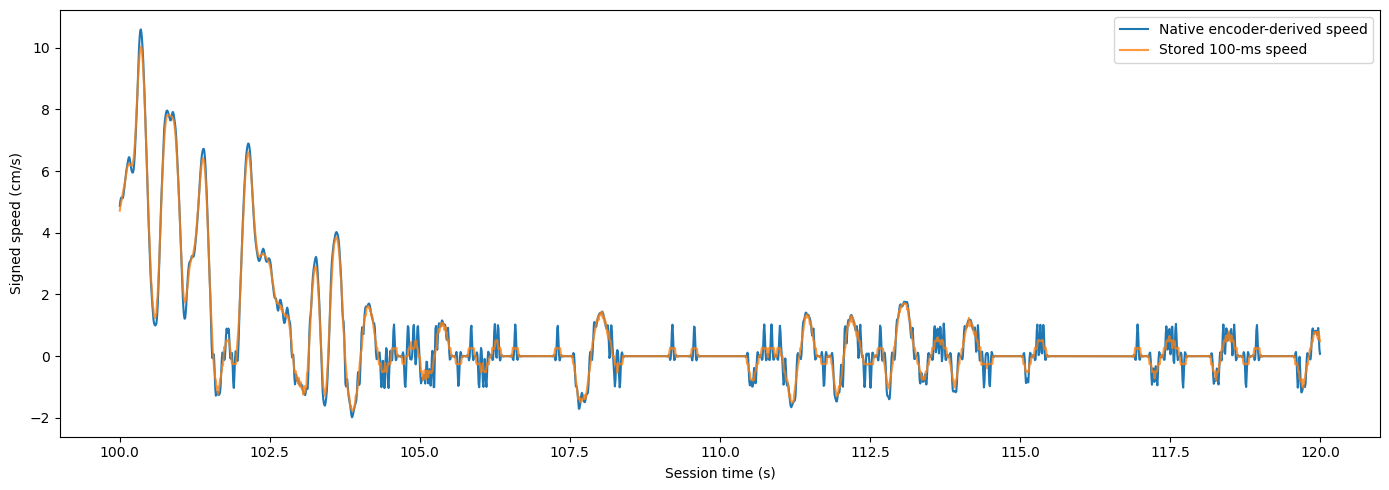

In [27]:
plot_start_s = 100
plot_end_s = 120

plot_df = spectral_df.loc[
    spectral_df["time_s"].between(
        plot_start_s,
        plot_end_s,
    )
]

fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    plot_df["time_s"],
    plot_df[
        "speed_encoder_derived_cms"
    ],
    label="Native encoder-derived speed",
)

ax.plot(
    plot_df["time_s"],
    plot_df[
        "speed_stored_cms"
    ],
    label="Stored 100-ms speed",
    alpha=0.8,
)

ax.set_xlabel("Session time (s)")
ax.set_ylabel("Signed speed (cm/s)")
ax.legend()

fig.tight_layout()
plt.show()

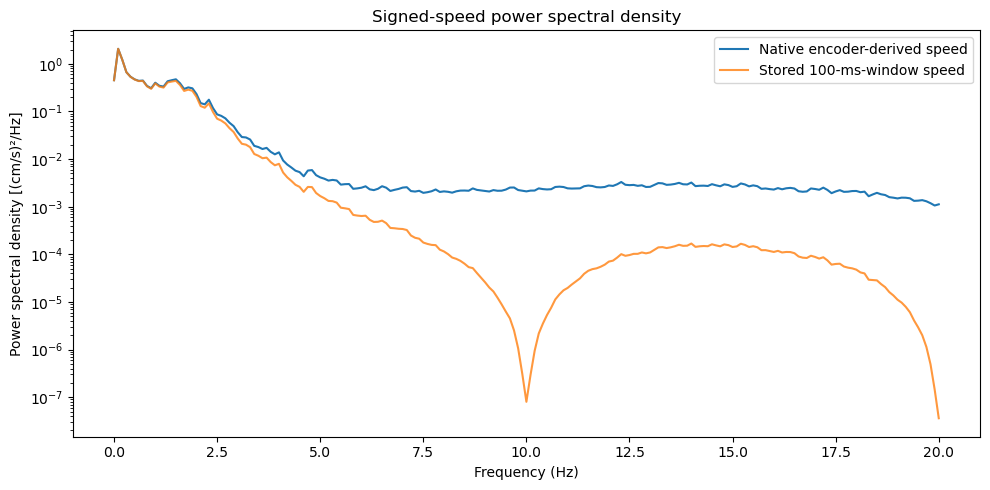

In [28]:
plot_speed_psd_comparison(
    spectral_df=spectral_df,
    spectral_config=spectral_config,
)

plt.show()

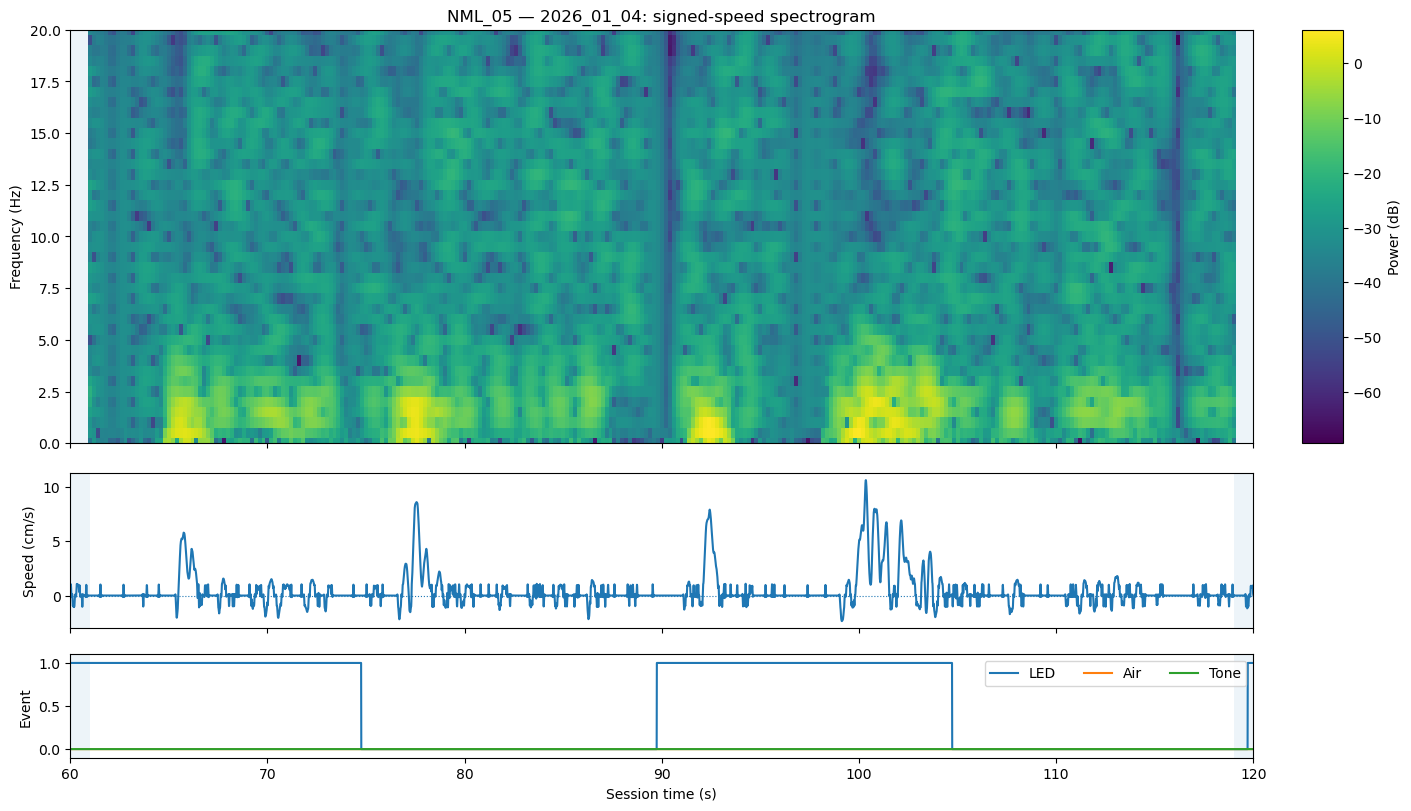

In [29]:
plot_speed_spectrogram(
    spectral_df=spectral_df,
    speed_column=(
        "speed_encoder_derived_cms"
    ),
    spectral_config=spectral_config,
    start_s=60,
    end_s=120,
)

plt.show()

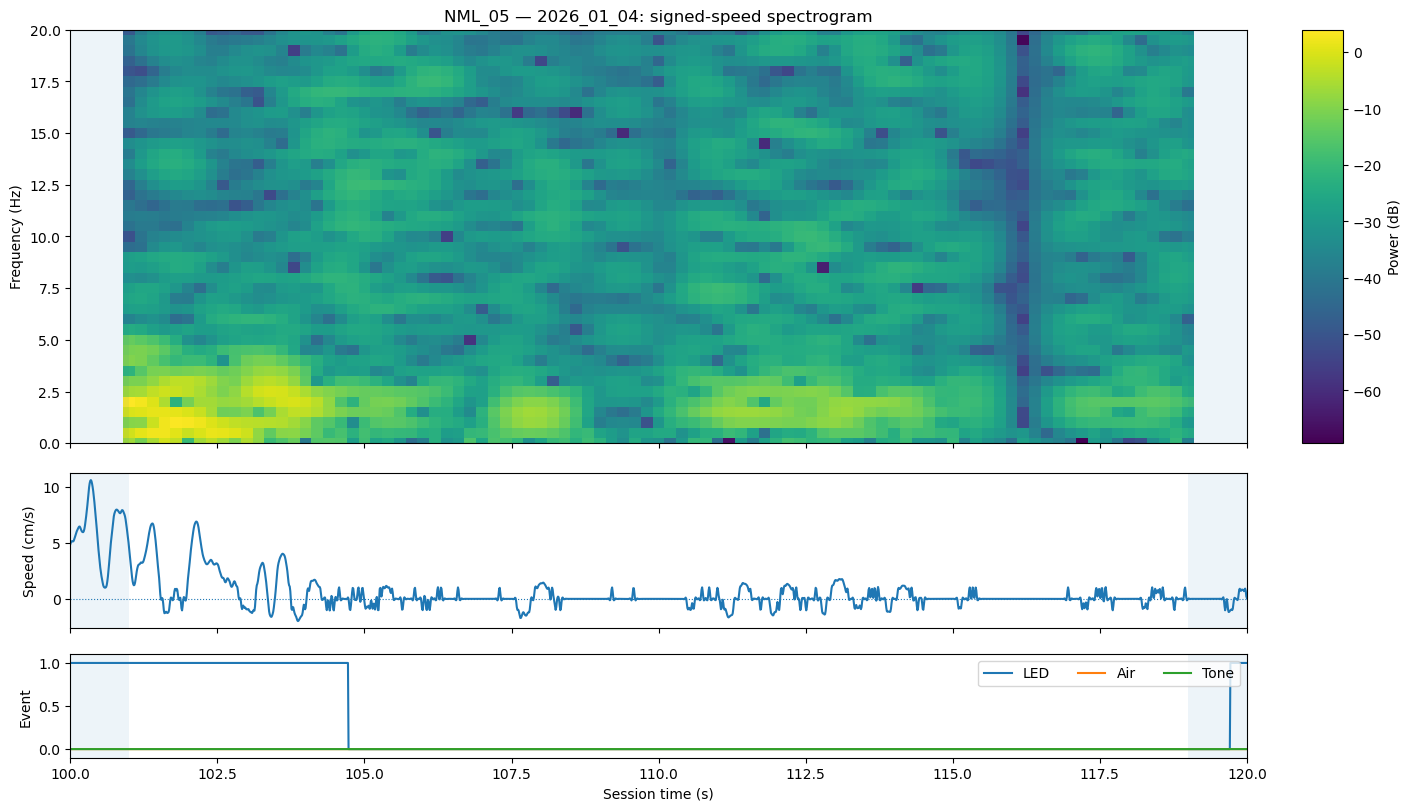

In [30]:
plot_speed_spectrogram(
    spectral_df=spectral_df,
    spectral_config=spectral_config,
    start_s=100,
    end_s=120,
)

plt.show()